# 04 — Visualization

**Task 5：** 產出摘要圖表（dpi=300）。資料為逐季 **`batting_clustered`**。

隔年 wRC+ 預測圖（importance、實際 vs 預測）請見 **`03_analysis`** 產生之 `figures/projection_*.png`。

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patches as mpatches
import glob
from pathlib import Path

matplotlib.rcParams['font.family'] = ['Arial Unicode MS', 'DejaVu Sans']
plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 300})
%matplotlib inline

PROC_DIR = Path('../data/processed')
RAW_DIR  = Path('../data/raw')
FIG_DIR  = Path('../figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

COLOR_MAP = {'工具型': '#E63946', '強打型': '#457B9D', '選球型': '#2A9D8F', '接觸型': '#E9C46A'}

## 圖 1：wRC+ 排名橫條圖

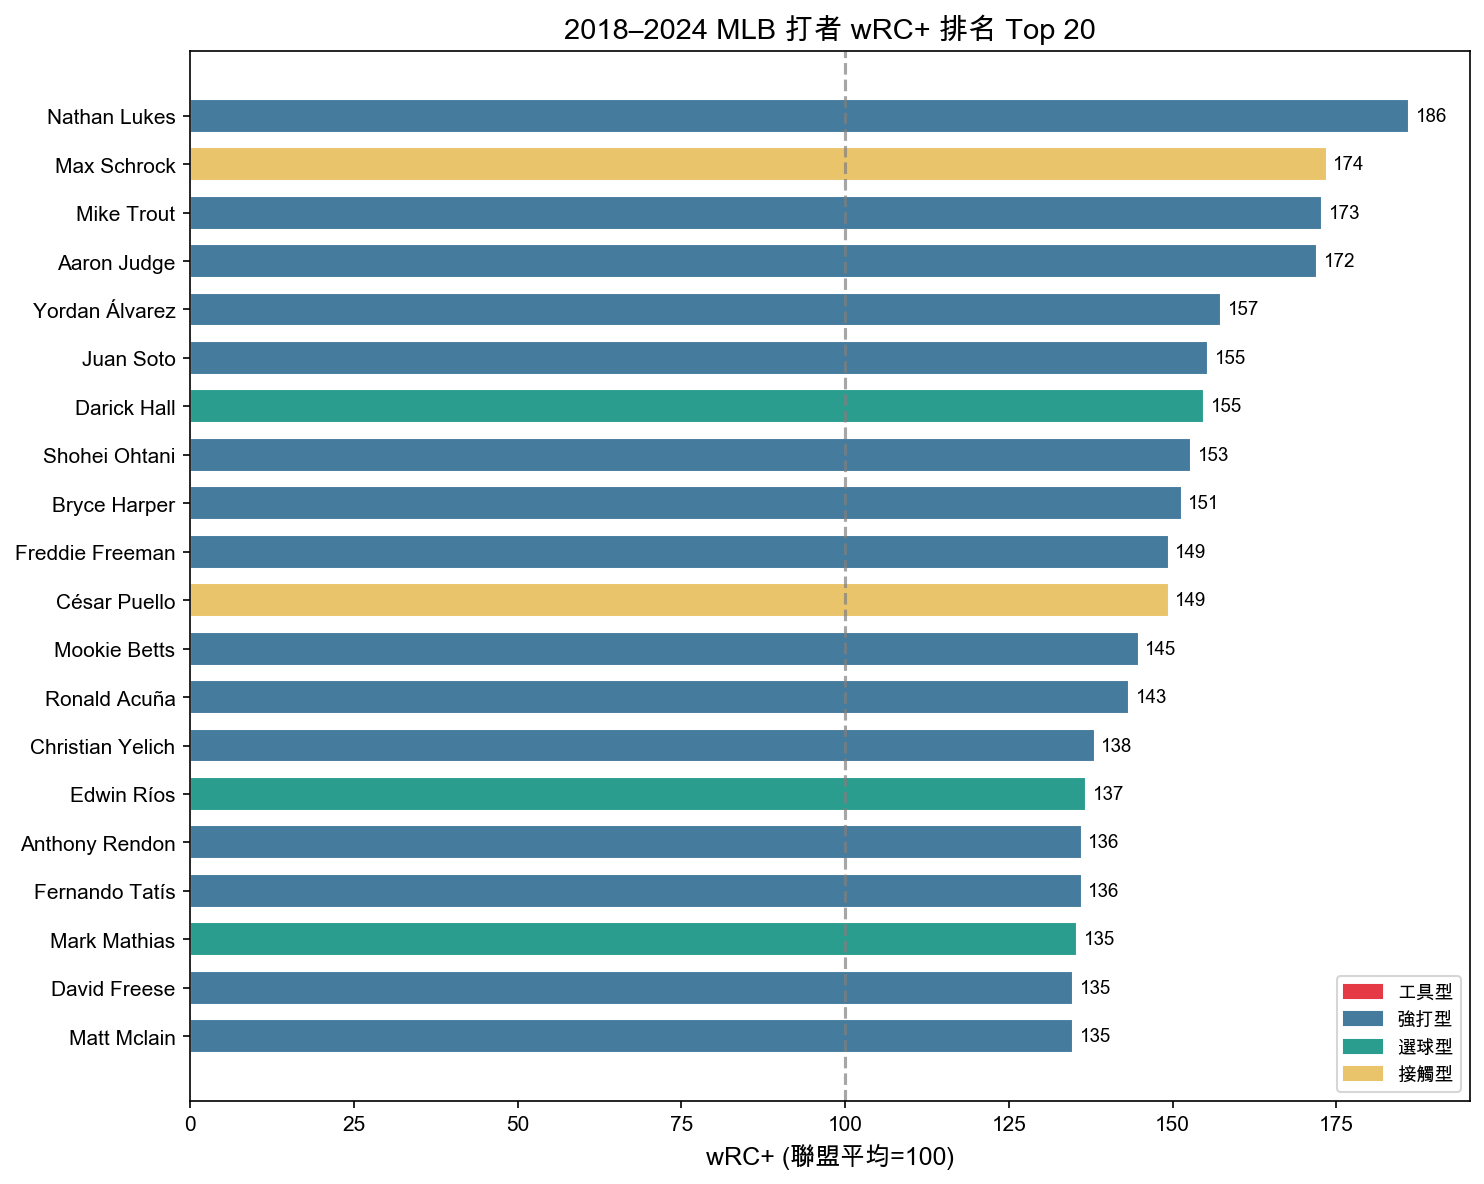

圖1 已儲存


In [2]:
df = pd.read_csv(PROC_DIR / 'batting_clustered.csv')
top20 = df.nlargest(20, 'wRC+').sort_values('wRC+')

colors = top20['cluster_name'].map(COLOR_MAP).fillna('#AAAAAA')

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top20['Name'], top20['wRC+'], color=colors, edgecolor='white', height=0.7)

for bar, val in zip(bars, top20['wRC+']):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}', va='center', fontsize=9)

ax.axvline(100, color='gray', linestyle='--', alpha=0.7, label='聯盟平均 (100)')
ax.set_xlabel('wRC+ (聯盟平均=100)', fontsize=12)
ax.set_title('2018–2024 MLB 打者 wRC+ 排名 Top 20', fontsize=14, fontweight='bold')

patches_legend = [mpatches.Patch(color=v, label=k) for k, v in COLOR_MAP.items()]
ax.legend(handles=patches_legend, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_wrcplus_ranking.png', dpi=300, bbox_inches='tight')
plt.show()
print('圖1 已儲存')

## 圖 2：WAR vs wRC+ 四象限散點圖

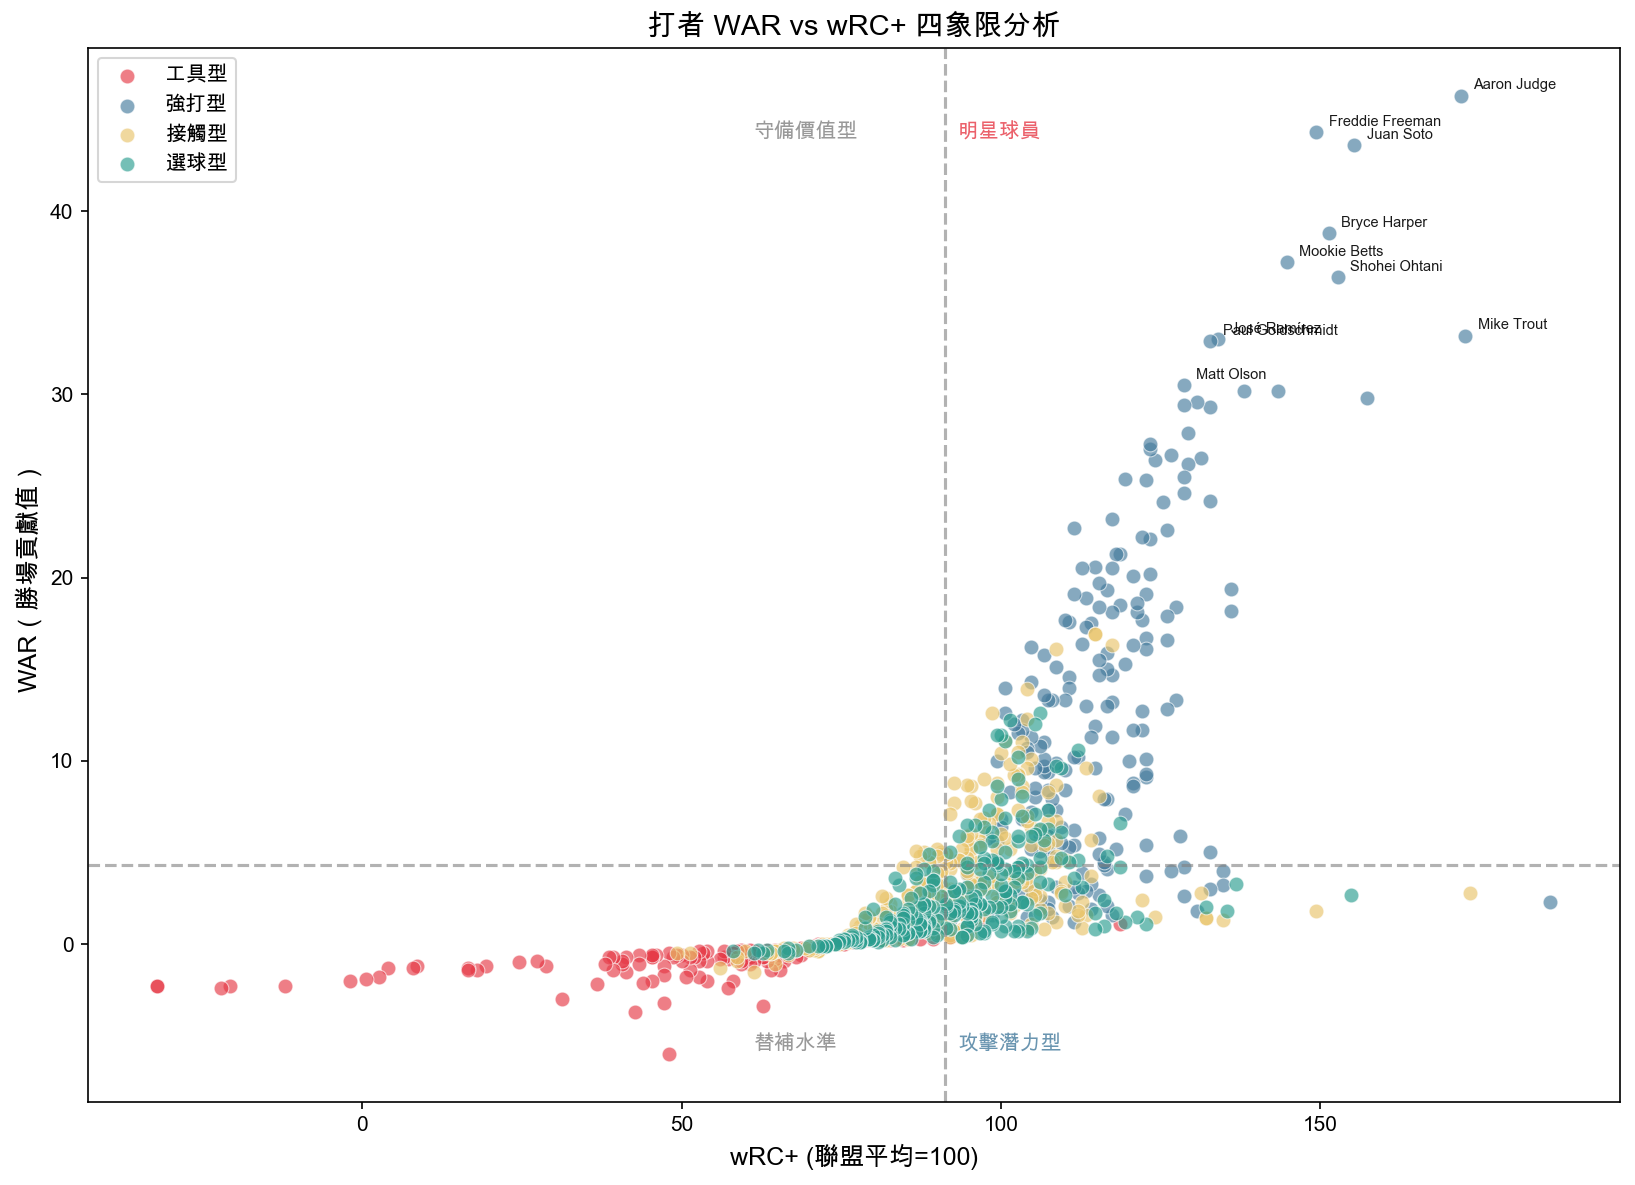

圖2 已儲存


In [3]:
fig, ax = plt.subplots(figsize=(11, 8))

war_mean = df['WAR'].mean()
wrc_mean = df['wRC+'].mean()

for cluster, group in df.groupby('cluster_name'):
    ax.scatter(group['wRC+'], group['WAR'],
               label=cluster, color=COLOR_MAP.get(cluster, '#AAAAAA'),
               alpha=0.65, s=50, edgecolors='white', linewidths=0.5)

ax.axvline(wrc_mean, color='gray', linestyle='--', alpha=0.6)
ax.axhline(war_mean, color='gray', linestyle='--', alpha=0.6)

ax.text(wrc_mean + 2,  df['WAR'].max() * 0.95, '明星球員',   fontsize=10, color='#E63946', alpha=0.8)
ax.text(wrc_mean - 30, df['WAR'].max() * 0.95, '守備價值型', fontsize=10, color='gray',    alpha=0.8)
ax.text(wrc_mean + 2,  df['WAR'].min() + 0.2,  '攻擊潛力型', fontsize=10, color='#457B9D', alpha=0.8)
ax.text(wrc_mean - 30, df['WAR'].min() + 0.2,  '替補水準',   fontsize=10, color='gray',    alpha=0.8)

top10 = df.nlargest(10, 'WAR')
for _, row in top10.iterrows():
    ax.annotate(row['Name'], (row['wRC+'], row['WAR']),
                textcoords='offset points', xytext=(6, 3), fontsize=7, alpha=0.9)

ax.set_xlabel('wRC+ (聯盟平均=100)', fontsize=12)
ax.set_ylabel('WAR（勝場貢獻值）', fontsize=12)
ax.set_title('打者 WAR vs wRC+ 四象限分析', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_war_vs_wrcplus.png', dpi=300, bbox_inches='tight')
plt.show()
print('圖2 已儲存')

## 圖 3：多球員雷達圖（蜘蛛網圖）

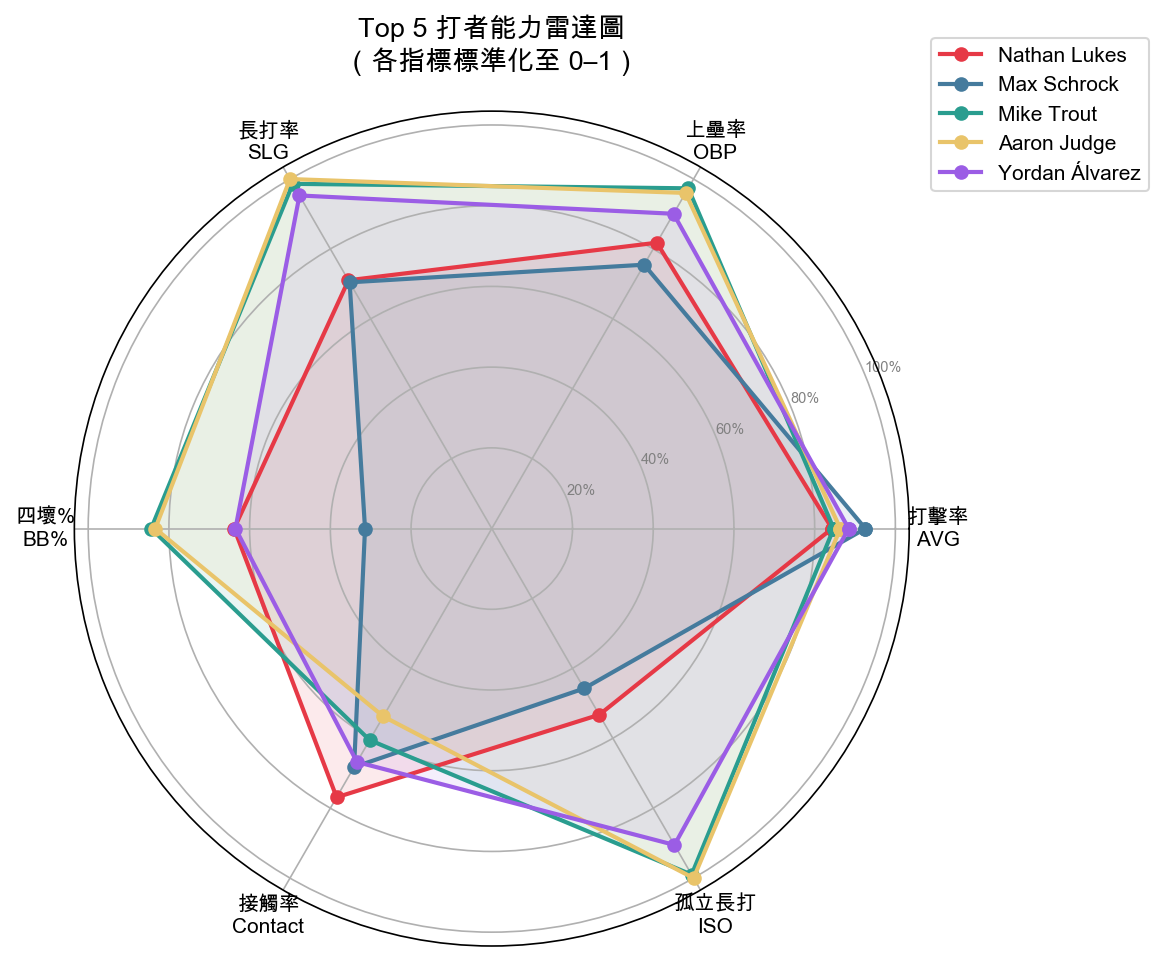

圖3 已儲存


In [4]:
df_clean  = pd.read_csv(PROC_DIR / 'batting_clean.csv')
df_scaled = pd.read_csv(PROC_DIR / 'batting_scaled.csv')
df_scaled['Name'] = df_clean['Name'].values

selected_names = df_clean.nlargest(5, 'wRC+')['Name'].tolist()

radar_features = ['AVG', 'OBP', 'SLG', 'BB%', 'contact_rate', 'ISO']
radar_features = [f for f in radar_features if f in df_scaled.columns]
categories = ['打擊率\nAVG', '上壘率\nOBP', '長打率\nSLG',
              '四壞%\nBB%', '接觸率\nContact', '孤立長打\nISO']
categories = categories[:len(radar_features)]
N = len(radar_features)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

colors_radar = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#9B5DE5']

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, name in enumerate(selected_names):
    row = df_scaled[df_scaled['Name'] == name]
    if row.empty:
        continue
    values = row[radar_features].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=colors_radar[i], label=name)
    ax.fill(angles, values, alpha=0.1, color=colors_radar[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=7, color='gray')
ax.set_title('Top 5 打者能力雷達圖\n（各指標標準化至 0–1）',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_radar_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print('圖3 已儲存')

## 圖 4：熱區圖 — 全打席進壘點密度

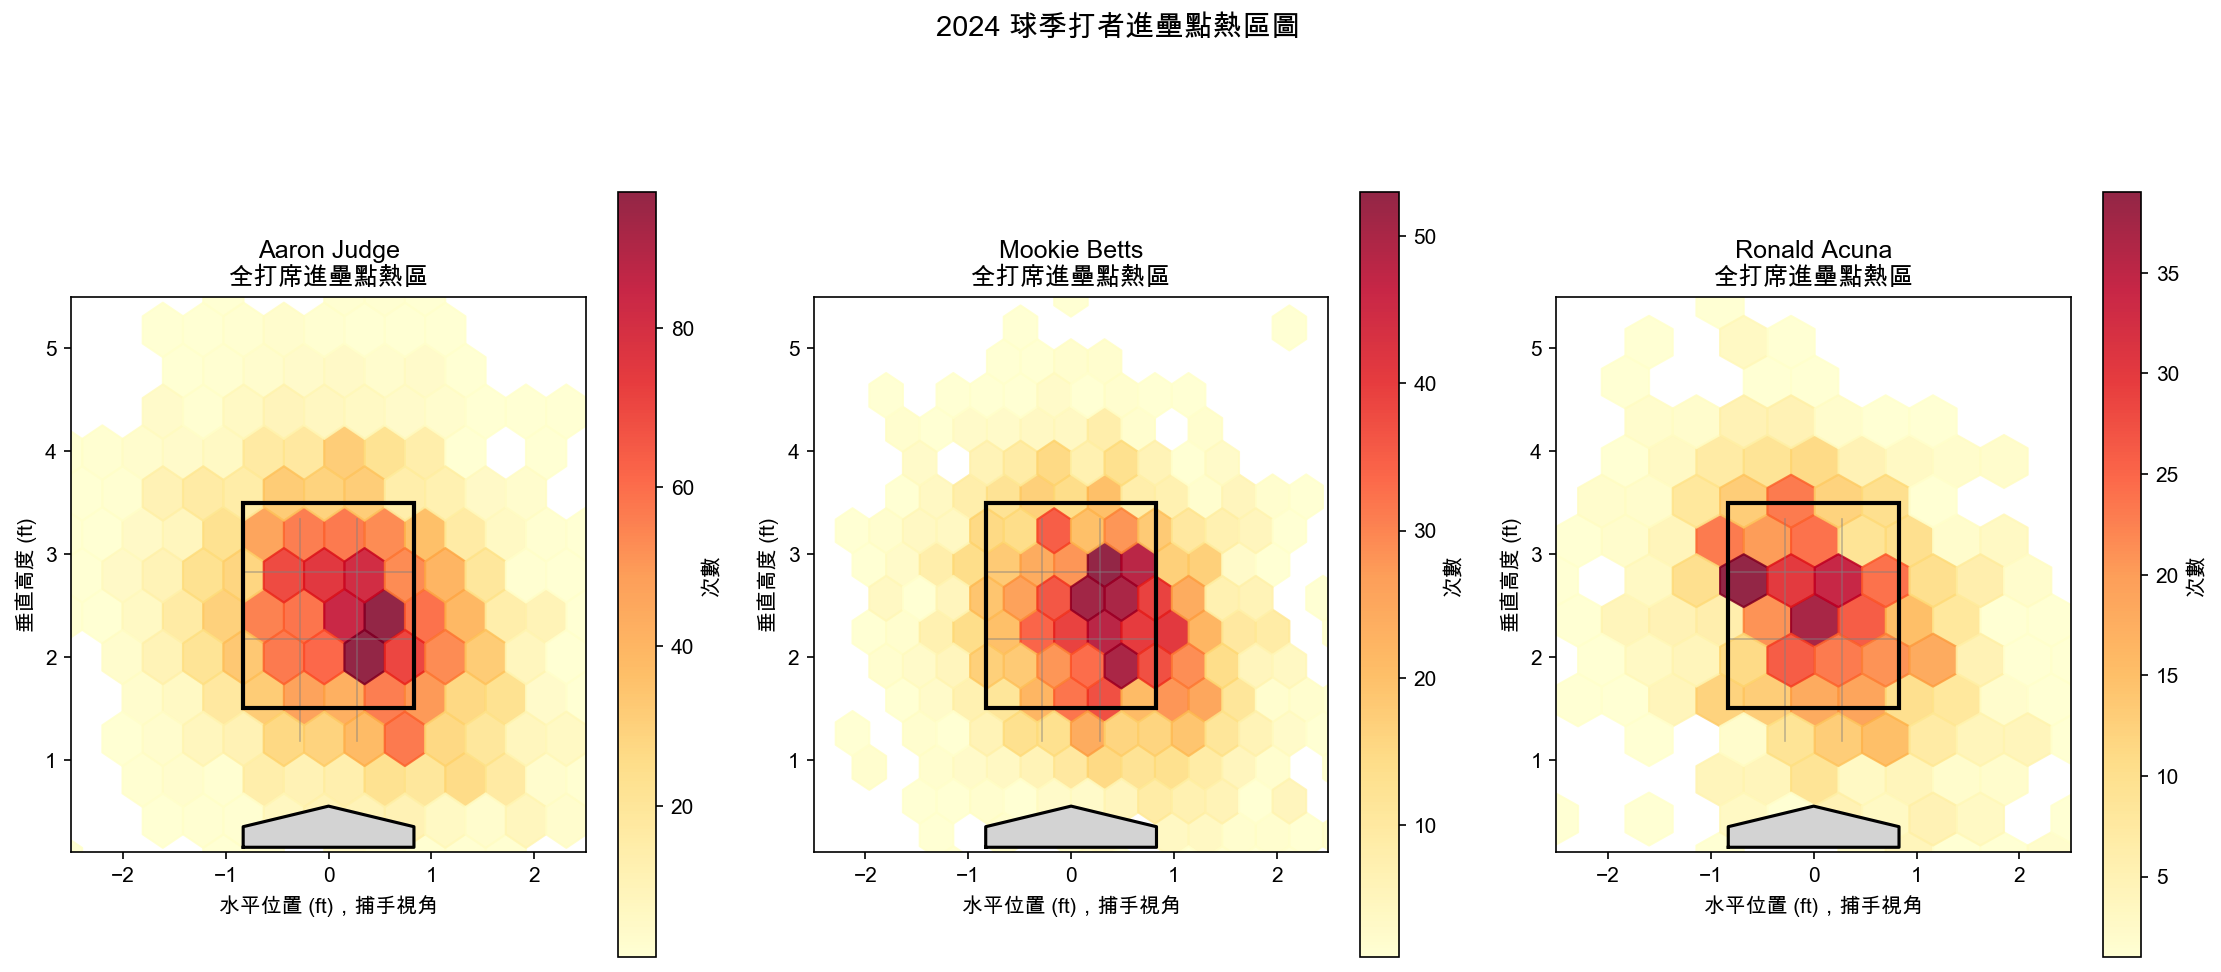

圖4 已儲存


In [5]:
files = sorted(glob.glob(str(RAW_DIR / 'statcast_*_2024.csv')))

if not files:
    print('找不到 statcast_*.csv，請先執行 01_data_collection.ipynb')
else:
    fig, axes = plt.subplots(1, len(files), figsize=(5 * len(files), 7))
    if len(files) == 1:
        axes = [axes]

    for ax, f in zip(axes, files):
        fname = Path(f).stem  # e.g. statcast_aaron_judge_2024
        player_name = fname.replace('statcast_', '').replace('_2024', '').replace('_', ' ').title()
        df_p = pd.read_csv(f).dropna(subset=['plate_x', 'plate_z'])

        # 好球帶框（MLB 標準）
        sz = patches.Rectangle((-0.83, 1.5), 1.66, 2.0,
                                linewidth=2, edgecolor='black', facecolor='none', zorder=3)
        ax.add_patch(sz)

        # 好球帶九宮格
        for x in [-0.28, 0.28]:
            ax.axvline(x, ymin=(1.5 - 0.5) / 5, ymax=(3.5 - 0.5) / 5,
                       color='gray', linewidth=0.8, alpha=0.5)
        for y in [2.17, 2.83]:
            ax.axhline(y, xmin=((-0.83 + 2.5) / 5), xmax=((0.83 + 2.5) / 5),
                       color='gray', linewidth=0.8, alpha=0.5)

        hb = ax.hexbin(df_p['plate_x'], df_p['plate_z'],
                       gridsize=18, cmap='YlOrRd', mincnt=1, alpha=0.85)
        plt.colorbar(hb, ax=ax, label='次數', shrink=0.8)

        home_plate_x = [-0.83, 0.83, 0.83,  0, -0.83]
        home_plate_y = [0.15,  0.15, 0.35, 0.55, 0.35]
        ax.fill(home_plate_x, home_plate_y, color='lightgray', zorder=2)
        ax.plot(home_plate_x + [home_plate_x[0]],
                home_plate_y + [home_plate_y[0]], 'k-', linewidth=1.5, zorder=3)

        ax.set_xlim(-2.5, 2.5)
        ax.set_ylim(0.1, 5.5)
        ax.set_xlabel('水平位置 (ft)，捕手視角', fontsize=10)
        ax.set_ylabel('垂直高度 (ft)', fontsize=10)
        ax.set_title(f'{player_name}\n全打席進壘點熱區', fontsize=12, fontweight='bold')
        ax.set_aspect('equal')

    plt.suptitle('2024 球季打者進壘點熱區圖', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig4_heatmap_all.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('圖4 已儲存')

## 圖 5：熱區圖 — 依打擊結果分色

/var/folders/dd/lvq9qdhx4hb5xlkhqfvdk7w80000gn/T/ipykernel_86495/3173031401.py:30: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(sub['plate_x'], sub['plate_z'],


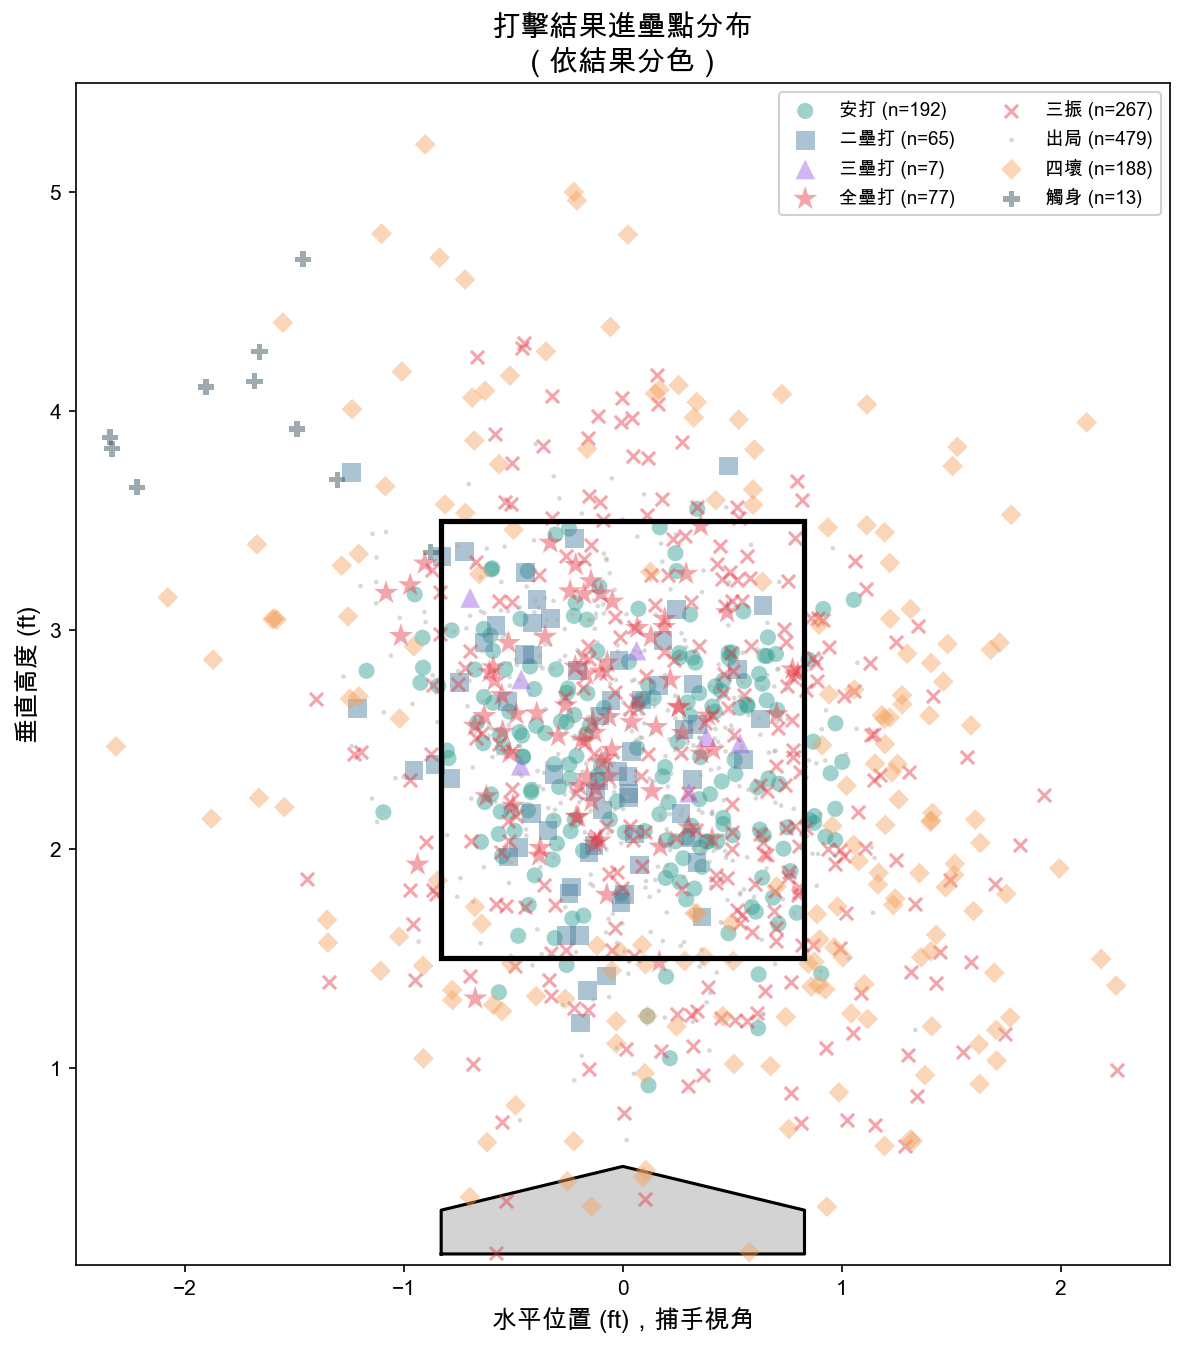

圖5 已儲存


In [6]:
files = sorted(glob.glob(str(RAW_DIR / 'statcast_*_2024.csv')))

if not files:
    print('找不到 statcast_*.csv，請先執行 01_data_collection.ipynb')
else:
    df_all = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    df_all = df_all.dropna(subset=['plate_x', 'plate_z', 'events'])

    result_map = {
        'single':       ('安打',   '#2A9D8F', 'o',  60),
        'double':       ('二壘打', '#457B9D', 's',  80),
        'triple':       ('三壘打', '#9B5DE5', '^',  90),
        'home_run':     ('全壘打', '#E63946', '*', 150),
        'strikeout':    ('三振',   '#E63946', 'x',  40),
        'field_out':    ('出局',   '#AAAAAA', '.',  20),
        'walk':         ('四壞',   '#F4A261', 'D',  50),
        'hit_by_pitch': ('觸身',   '#264653', 'P',  60),
    }

    fig, ax = plt.subplots(figsize=(8, 9))

    sz = patches.Rectangle((-0.83, 1.5), 1.66, 2.0,
                            linewidth=2.5, edgecolor='black', facecolor='none', zorder=5)
    ax.add_patch(sz)

    for event, (label, color, marker, size) in result_map.items():
        sub = df_all[df_all['events'] == event]
        if sub.empty:
            continue
        ax.scatter(sub['plate_x'], sub['plate_z'],
                   c=color, marker=marker, s=size,
                   alpha=0.45, label=f'{label} (n={len(sub)})',
                   edgecolors='none', zorder=4)

    home_plate_x = [-0.83, 0.83, 0.83,  0, -0.83]
    home_plate_y = [0.15,  0.15, 0.35, 0.55, 0.35]
    ax.fill(home_plate_x, home_plate_y, color='lightgray', zorder=2)
    ax.plot(home_plate_x + [home_plate_x[0]],
            home_plate_y + [home_plate_y[0]], 'k-', linewidth=1.5, zorder=3)

    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(0.1, 5.5)
    ax.set_xlabel('水平位置 (ft)，捕手視角', fontsize=12)
    ax.set_ylabel('垂直高度 (ft)', fontsize=12)
    ax.set_title('打擊結果進壘點分布\n（依結果分色）', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9, framealpha=0.9, ncol=2)
    ax.set_aspect('equal')

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig5_heatmap_by_result.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('圖5 已儲存')

## 完成確認

In [7]:
expected_figs = [
    'fig1_wrcplus_ranking.png',
    'fig2_war_vs_wrcplus.png',
    'fig3_radar_chart.png',
    'fig4_heatmap_all.png',
    'fig5_heatmap_by_result.png',
]
expected_data = [
    '../data/processed/batting_clean.csv',
    '../data/processed/batting_scaled.csv',
    '../data/processed/batting_clustered.csv',
]

print('=== 圖表輸出 ===')
for f in expected_figs:
    p = FIG_DIR / f
    status = '✅' if p.exists() else '❌'
    print(f'  {status} {f}')

print('\n=== 資料輸出 ===')
for f in expected_data:
    p = Path(f)
    status = '✅' if p.exists() else '❌'
    print(f'  {status} {p.name}')

=== 圖表輸出 ===
  ✅ fig1_wrcplus_ranking.png
  ✅ fig2_war_vs_wrcplus.png
  ✅ fig3_radar_chart.png
  ✅ fig4_heatmap_all.png
  ✅ fig5_heatmap_by_result.png

=== 資料輸出 ===
  ✅ batting_clean.csv
  ✅ batting_scaled.csv
  ✅ batting_clustered.csv


## 圖 9：xBA vs 實際 BA — 運氣修正分析

從 Statcast 的 `estimated_ba_using_speedangle`（期望打擊率 xBA）對比實際打擊率 BA，  
找出「打得比物理預期好」（好運型）vs「打得比物理預期差」（被壓制型）的球員。

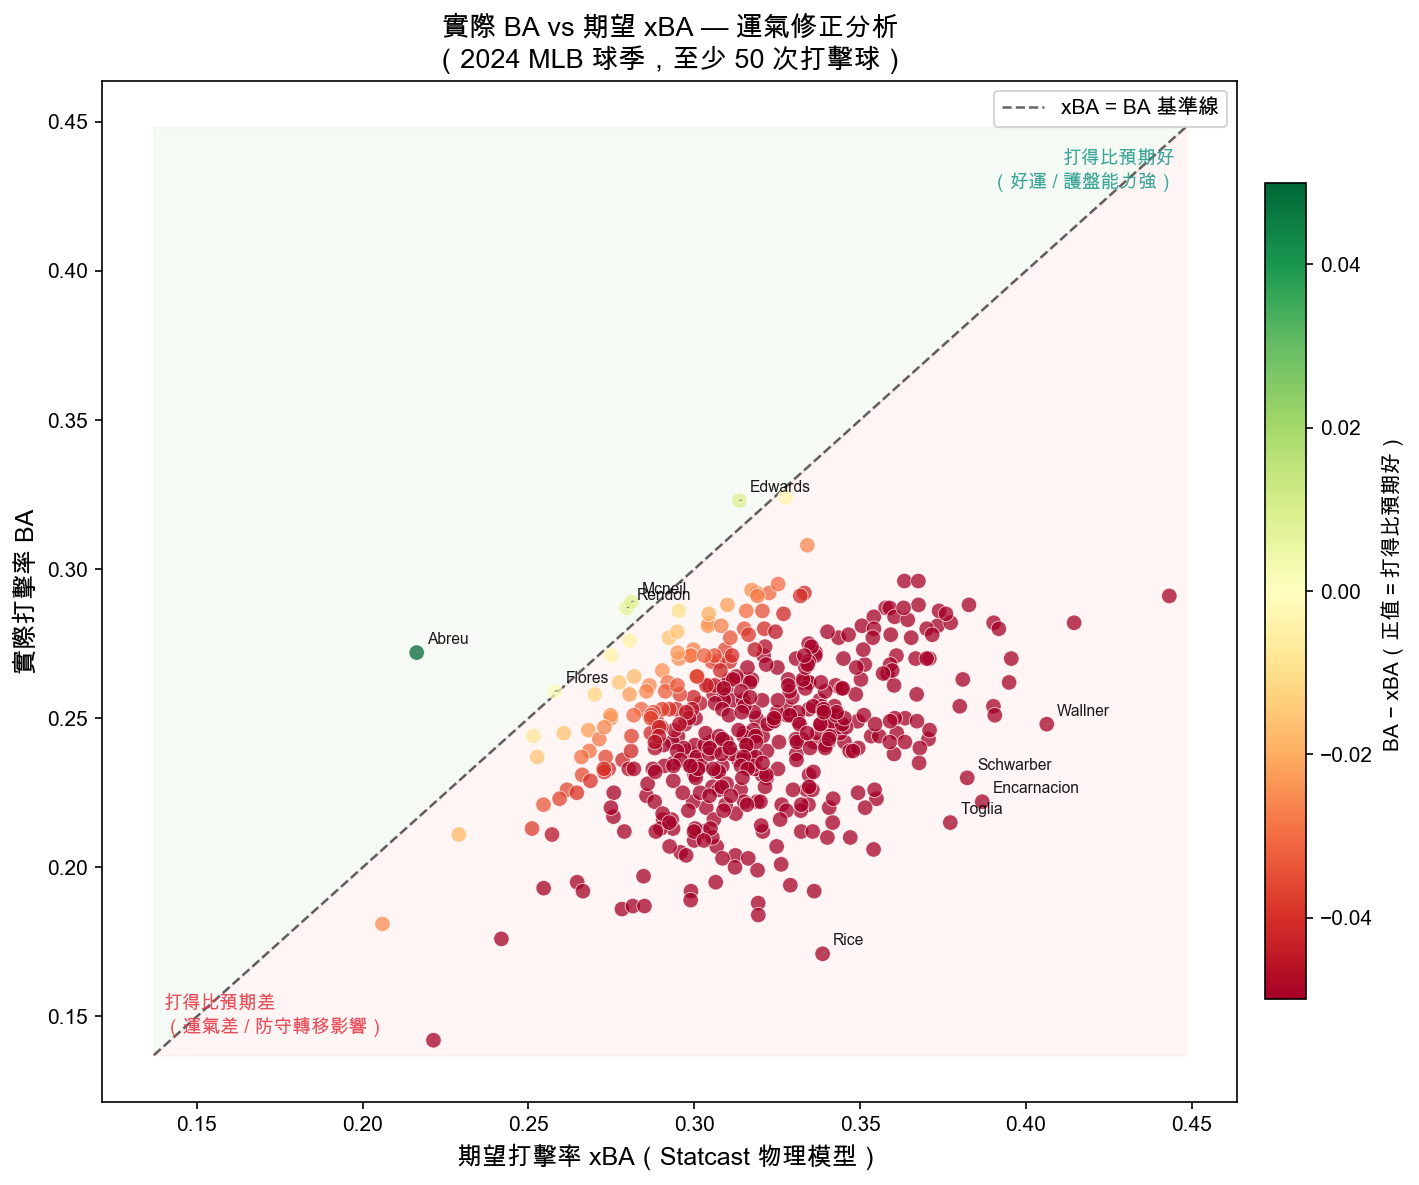

圖9 已儲存

最「幸運」前5（BA遠高於xBA）：
          Name   AVG  xBA_mean   diff
    José Abreu 0.272     0.216  0.056
Xavier Edwards 0.323     0.314  0.009
   Jeff Mcneil 0.289     0.281  0.008
Anthony Rendon 0.287      0.28  0.007
 Wilmer Flores 0.259     0.258  0.001

最「被低估」前5（BA遠低於xBA）：
             Name   AVG  xBA_mean   diff
         Ben Rice 0.171     0.339 -0.168
Jerar Encarnacion 0.222     0.387 -0.165
   Michael Toglia 0.215     0.377 -0.162
     Matt Wallner 0.248     0.406 -0.158
   Kyle Schwarber 0.230     0.382 -0.152


In [ ]:
from pybaseball import playerid_reverse_lookup, cache
cache.enable()

# ── Compute per-batter xBA and actual BA from statcast ────────────────────────
sc = pd.read_parquet(RAW_DIR / 'statcast_2024.parquet')

PA_EVENTS = {
    'single', 'double', 'triple', 'home_run',
    'strikeout', 'strikeout_double_play',
    'field_out', 'force_out', 'grounded_into_double_play',
    'double_play', 'fielders_choice', 'fielders_choice_out',
    'field_error', 'sac_fly', 'sac_fly_double_play',
}
sc_batted = sc[
    sc['events'].isin(PA_EVENTS) &
    sc['estimated_ba_using_speedangle'].notna()
].copy()

batter_xba = (
    sc_batted
    .groupby('batter')
    .agg(
        xBA_mean=('estimated_ba_using_speedangle', 'mean'),
        n_batted=('estimated_ba_using_speedangle', 'count'),
    )
    .reset_index()
)

# Get player names for MLBAM IDs
sc_pa_ids = sc_batted[['batter']].drop_duplicates()
ndf = playerid_reverse_lookup(sc_pa_ids['batter'].astype(int).tolist(), key_type='mlbam')
ndf['Name'] = ndf['name_first'].str.title() + ' ' + ndf['name_last'].str.title()
ndf = ndf.rename(columns={'key_mlbam': 'batter'})
df_xba = batter_xba.merge(ndf[['batter', 'Name']], on='batter', how='left')
df_xba = df_xba.dropna(subset=['Name'])

# Merge with actual batting stats
batting = pd.read_csv(RAW_DIR / 'batting_stats_2018_2024.csv')
df9 = batting.merge(df_xba[['Name', 'xBA_mean', 'n_batted']], on='Name', how='inner')
df9 = df9[df9['n_batted'] >= 50].copy()

df9['diff'] = df9['AVG'] - df9['xBA_mean']

lucky   = df9.nlargest(5, 'diff')
unlucky = df9.nsmallest(5, 'diff')

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

sc_plot = ax.scatter(df9['xBA_mean'], df9['AVG'],
                     c=df9['diff'], cmap='RdYlGn', vmin=-0.05, vmax=0.05,
                     s=55, alpha=0.75, edgecolors='white', linewidths=0.4, zorder=3)

lo = min(df9['xBA_mean'].min(), df9['AVG'].min()) - 0.005
hi = max(df9['xBA_mean'].max(), df9['AVG'].max()) + 0.005
ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1.2, alpha=0.6, label='xBA = BA 基準線', zorder=2)

ax.fill_between([lo, hi], [lo, hi], [hi, hi], alpha=0.04, color='green', zorder=1)
ax.fill_between([lo, hi], [lo, lo], [lo, hi], alpha=0.04, color='red',   zorder=1)

ax.text(hi - 0.003, hi - 0.008, '打得比預期好\n（好運 / 護盤能力強）',
        ha='right', va='top', fontsize=9, color='#2A9D8F', alpha=0.9)
ax.text(lo + 0.003, lo + 0.006, '打得比預期差\n（運氣差 / 防守轉移影響）',
        ha='left', va='bottom', fontsize=9, color='#E63946', alpha=0.9)

# Annotate outliers
for _, row in pd.concat([lucky, unlucky]).iterrows():
    ax.annotate(
        row['Name'].split()[-1],
        (row['xBA_mean'], row['AVG']),
        xytext=(5, 4), textcoords='offset points',
        fontsize=7.5, alpha=0.9,
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
    )

sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(-0.05, 0.05))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=0.8)
cbar.set_label('BA − xBA（正值＝打得比預期好）', fontsize=10)

ax.set_xlabel('期望打擊率 xBA（Statcast 物理模型）', fontsize=12)
ax.set_ylabel('實際打擊率 BA', fontsize=12)
ax.set_title('實際 BA vs 期望 xBA — 運氣修正分析\n（2024 MLB 球季，至少 50 次打擊球）',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig9_xba_vs_ba.png', dpi=300, bbox_inches='tight')
plt.show()
print('圖9 已儲存')
print(f'\n最「幸運」前5（BA遠高於xBA）：')
print(lucky[['Name', 'AVG', 'xBA_mean', 'diff']].round(3).to_string(index=False))
print(f'\n最「被低估」前5（BA遠低於xBA）：')
print(unlucky[['Name', 'AVG', 'xBA_mean', 'diff']].round(3).to_string(index=False))

## 圖 10：Aaron Judge 強區 vs 弱區分析

將 Judge 的熱區拆分為「正面結果（HR + 2B + 3B）」與「負面結果（三振）」，  
並排比較密度，揭示頂級球員的進壘點弱點。

Judge — 長打（HR/2B/3B）次數：94
Judge — 三振次數：164


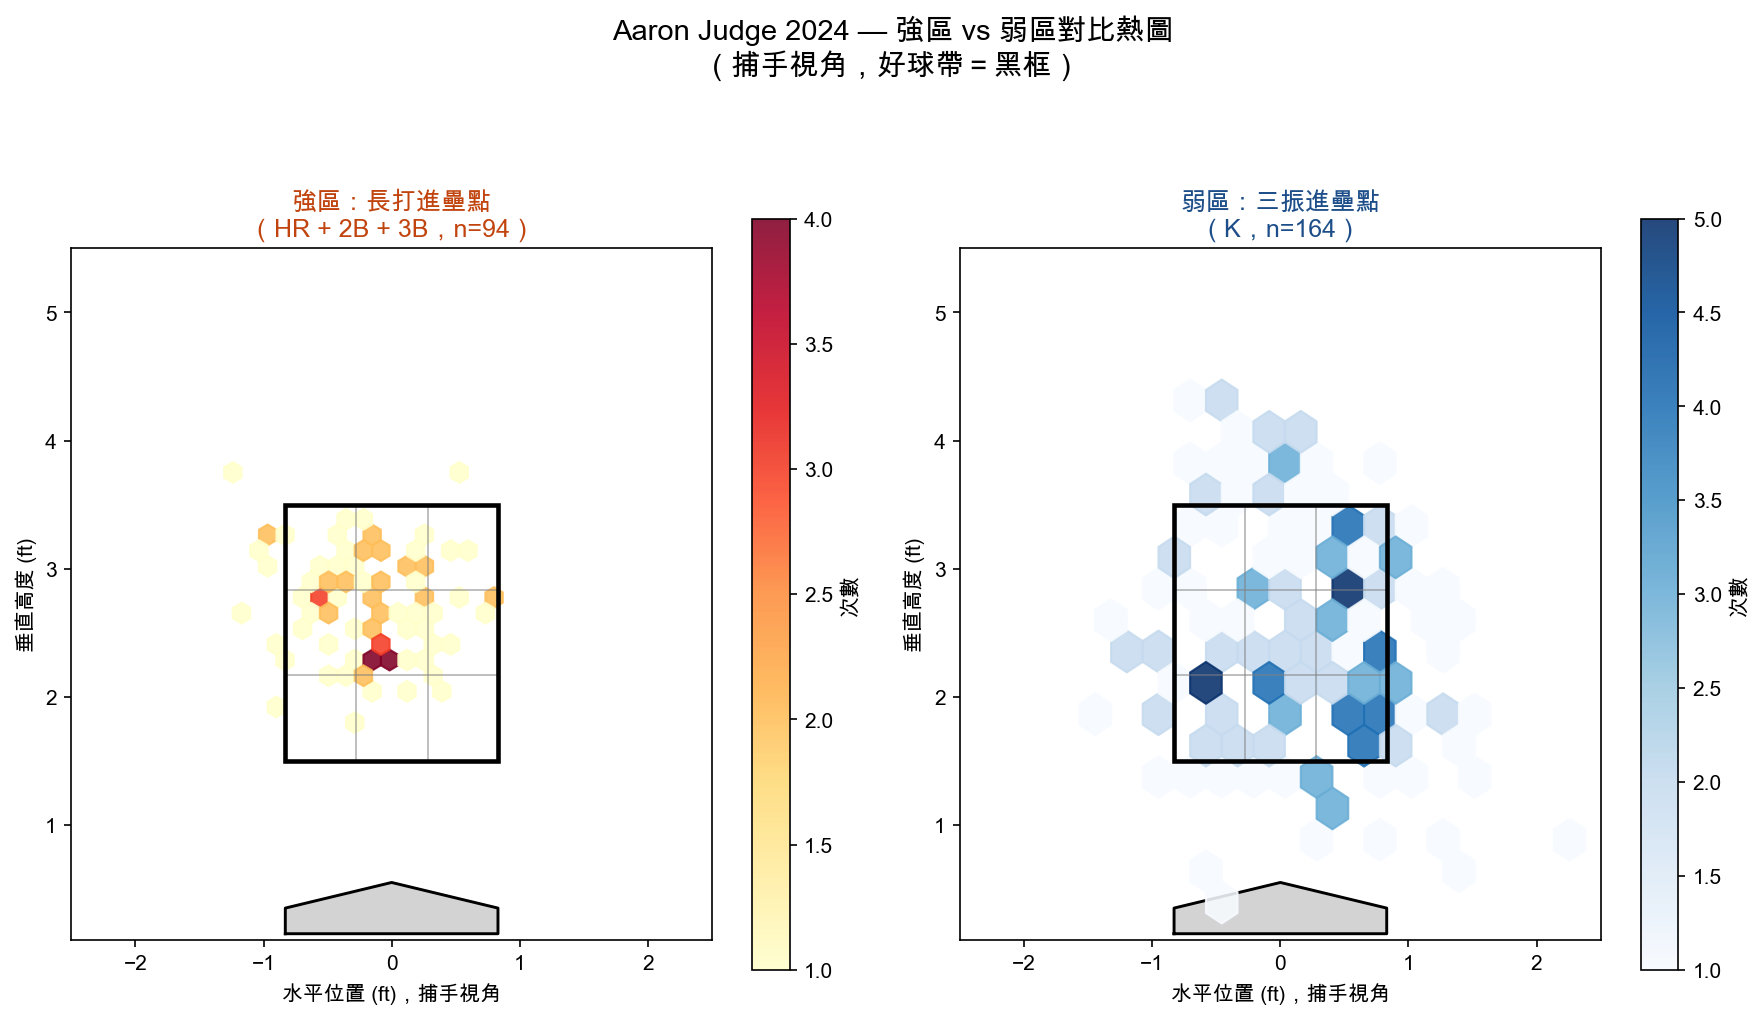

圖10 已儲存


In [ ]:
judge_path = RAW_DIR / 'statcast_aaron_judge_2024.csv'
dj = pd.read_csv(judge_path)
dj = dj.dropna(subset=['plate_x', 'plate_z', 'events'])

power_events    = {'home_run', 'double', 'triple'}
weakness_events = {'strikeout', 'strikeout_double_play'}

dj_power    = dj[dj['events'].isin(power_events)]
dj_weakness = dj[dj['events'].isin(weakness_events)]

print(f"Judge — 長打（HR/2B/3B）次數：{len(dj_power)}")
print(f"Judge — 三振次數：{len(dj_weakness)}")

def draw_strike_zone(ax):
    """Draw MLB standard strike zone box and 9-zone grid."""
    sz = patches.Rectangle((-0.83, 1.5), 1.66, 2.0,
                            linewidth=2.2, edgecolor='black', facecolor='none', zorder=5)
    ax.add_patch(sz)
    # 3x3 grid lines inside zone
    for xv in [-0.28, 0.28]:
        ax.vlines(xv, 1.5, 3.5, colors='gray', linewidth=0.8, alpha=0.6, zorder=4)
    for yv in [2.17, 2.83]:
        ax.hlines(yv, -0.83, 0.83, colors='gray', linewidth=0.8, alpha=0.6, zorder=4)
    # Home plate
    hpx = [-0.83, 0.83, 0.83,  0, -0.83]
    hpy = [0.15,  0.15, 0.35, 0.55, 0.35]
    ax.fill(hpx, hpy, color='lightgray', zorder=2)
    ax.plot(hpx + [hpx[0]], hpy + [hpy[0]], 'k-', linewidth=1.4, zorder=3)

fig, axes = plt.subplots(1, 2, figsize=(12, 7))

GRIDSIZE = 15

# Left: Power zones (HR + XBH) — YlOrRd
ax = axes[0]
draw_strike_zone(ax)
hb1 = ax.hexbin(dj_power['plate_x'], dj_power['plate_z'],
                gridsize=GRIDSIZE, cmap='YlOrRd', mincnt=1, alpha=0.88, zorder=3)
cb1 = plt.colorbar(hb1, ax=ax, shrink=0.82, label='次數')
ax.set_xlim(-2.5, 2.5); ax.set_ylim(0.1, 5.5)
ax.set_aspect('equal')
ax.set_xlabel('水平位置 (ft)，捕手視角', fontsize=10)
ax.set_ylabel('垂直高度 (ft)', fontsize=10)
ax.set_title(f'強區：長打進壘點\n（HR + 2B + 3B，n={len(dj_power)}）',
             fontsize=12, fontweight='bold', color='#C1440E')

# Right: Weakness zones (Strikeouts) — Blues
ax = axes[1]
draw_strike_zone(ax)
hb2 = ax.hexbin(dj_weakness['plate_x'], dj_weakness['plate_z'],
                gridsize=GRIDSIZE, cmap='Blues', mincnt=1, alpha=0.88, zorder=3)
cb2 = plt.colorbar(hb2, ax=ax, shrink=0.82, label='次數')
ax.set_xlim(-2.5, 2.5); ax.set_ylim(0.1, 5.5)
ax.set_aspect('equal')
ax.set_xlabel('水平位置 (ft)，捕手視角', fontsize=10)
ax.set_ylabel('垂直高度 (ft)', fontsize=10)
ax.set_title(f'弱區：三振進壘點\n（K，n={len(dj_weakness)}）',
             fontsize=12, fontweight='bold', color='#1D4E89')

plt.suptitle('Aaron Judge 2024 — 強區 vs 弱區對比熱圖\n（捕手視角，好球帶＝黑框）',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig10_judge_power_vs_weak.png', dpi=300, bbox_inches='tight')
plt.show()
print('圖10 已儲存')